In [1]:
import math as maths

import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import easygems.healpix as egh

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
import warnings

# Suppress specific FutureWarnings matching the message pattern when using cat[...].to_dask()
warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [3]:
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['UK']

In [4]:
# Show UM sims:
[key for key in cat if key.startswith('um_')]

['um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_GAL9',
 'um_glm_n2560_RAL3p3']

## Demonstrate access using 5km RAL3 (um_glm_n2560_RAL3p3)

* This is the main hackathon simulation, and is complete as of 6/5/25 (i.e. all times/zooms stored)

In [65]:
sim = cat['um_glm_n2560_RAL3p3']

In [35]:
# Open a dataset

In [36]:
ds = ds.pipe(egh.attach_coords)

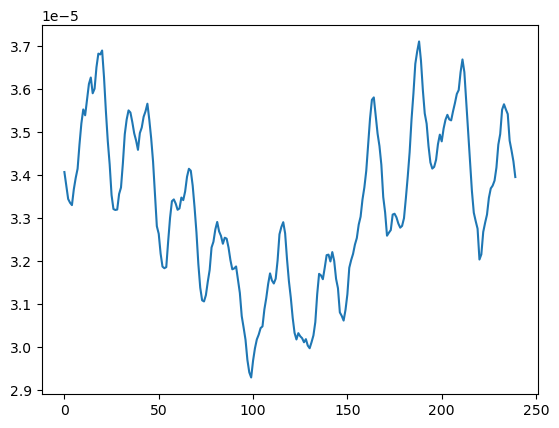

In [38]:
plt.plot(sim(zoom=9, time='PT1H').to_dask().sel(time=slice('2020-05-01 00:00', '2020-05-10 23:00')).pr.mean(dim='cell'))

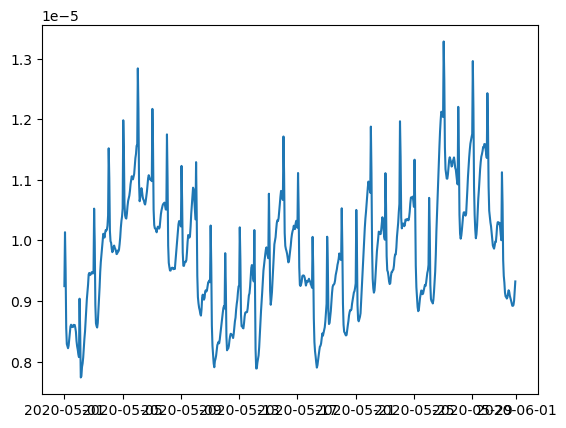

In [25]:
plt.plot(prts.time, prts.compute())

In [26]:
from pathlib import Path

In [27]:
import iris

In [28]:
paths = sorted(Path('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/').glob('glm.n1280_GAL9_nest.apverb_202005*.pp'))

In [47]:
paths

[PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200501T00.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200501T12.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200502T00.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200502T12.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200503T00.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200503T12.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n1280_GAL9_nest.apverb_20200504T00.pp'),
 PosixPath('/gws/nopw/j04/kscale/DYAMOND3_data/10km-GAL9-nest/glm/field.pp/apverb.pp/glm.n

In [62]:
cubes = iris.load(paths[:6])

In [63]:
ppt = cubes[31]

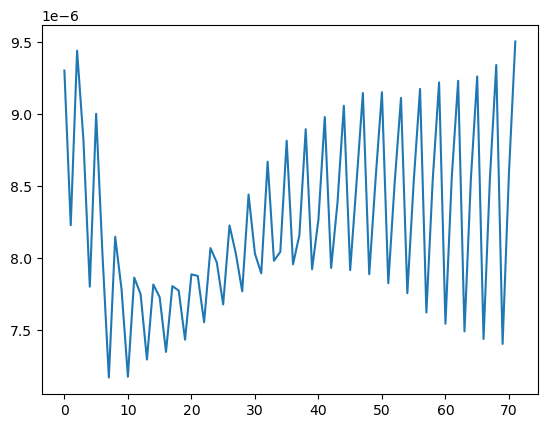

In [64]:
plt.plot(ppt.data.reshape(-1, *ppt.data.shape[2:]).mean(axis=(1, 2)))

In [46]:
cubes[31]

<iris 'Cube' of stratiform_rainfall_flux / (kg m-2 s-1) (forecast_period: 24; forecast_reference_time: 31; latitude: 1920; longitude: 2560)>